In [1]:
# Built-in
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, TimeDistributed, GlobalAveragePooling2D, LSTM, Dense, Dropout
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Scikit-learn
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)


In [2]:
# Define the path to the dataset
base_path = '/Users/admin/AIEngineer/ai-deepfake-cv-project/Dataset/Faceplus2'
categories = ['fake', 'real']

# Initialize a list to hold data
data = []

# Process each category
for category in categories:
    category_path = os.path.join(base_path, category)
    for filename in os.listdir(category_path):
        if filename.endswith('.jpg'):
            try:
                id_part, frame_part = filename.split('_frame_')
                id_ = id_part.split('_')[0]
                frame = frame_part.split('.')[0]
                data.append({
                    'filename': filename,
                    'path': os.path.join(category_path, filename),
                    'id': int(id_),
                    'frame': int(frame),
                    'label': category
                })
            except ValueError:
                continue

# Convert the data to a DataFrame
df = pd.DataFrame(data)

In [3]:
# Đảm bảo đã có df_cropped.csv chứa đường dẫn ảnh đã crop
df['label_id'] = df['label'].map({'fake': 0, 'real': 1})
df


,filename,path,id,frame,label,label_id
0,596_609_frame_0019.jpg,/Users/admin/AIEngineer/ai-deepfake-cv-project...,596,19,fake,0
1,746_571_frame_0008.jpg,/Users/admin/AIEngineer/ai-deepfake-cv-project...,746,8,fake,0
2,514_443_frame_0028.jpg,/Users/admin/AIEngineer/ai-deepfake-cv-project...,514,28,fake,0
3,642_635_frame_0006.jpg,/Users/admin/AIEngineer/ai-deepfake-cv-project...,642,6,fake,0
4,937_888_frame_0009.jpg,/Users/admin/AIEngineer/ai-deepfake-cv-project...,937,9,fake,0
...,...,...,...,...,...,...
59803,727_frame_0009.jpg,/Users/admin/AIEngineer/ai-deepfake-cv-project...,727,9,real,1
59804,832_frame_0026.jpg,/Users/admin/AIEngineer/ai-deepfake-cv-project...,832,26,real,1
59805,059_frame_0005.jpg,/Users/admin/AIEngineer/ai-deepfake-cv-project...,59,5,real,1
59806,572_frame_0008.jpg,/Users/admin/AIEngineer/ai-deepfake-cv-project...,572,8,real,1


In [4]:
df['video_key'] = df['id'].astype(str) + "_" + df['label']

from collections import defaultdict

video_dict = defaultdict(list)
labels = {}

for _, row in df.iterrows():
    key = row['video_key']
    video_dict[key].append(row['path'])
    labels[key] = row['label_id']


In [5]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(),"optimizer")))

from adamax_sgd_mix_new import AdamaxSGDMix, AlphaAnneal

In [6]:
import tensorflow as tf, keras, platform
print("arch:", platform.machine())
print("tf:", tf.__version__)
print("keras:", keras.__version__)
print("devices:", tf.config.list_physical_devices())

arch: arm64
tf: 2.15.1
keras: 2.15.0
devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [11]:
# ============================================================
# Full Script: MobileNetV2 → BiLSTM(96) → DenseKAN
# - Mixed precision (safe cast output -> float32)
# - Dataloader có temporal jitter + augment đúng chuẩn MBV2
# - Unfreeze dần backbone sau warmup
# - K-Fold (resume/skip từng fold, class weight)
# - Calibrate Temperature + Threshold trên VAL
# - TTA (flip) + HMM (auto-guard khi ít điểm)
# - Safe load weights (by_name + skip_mismatch nếu cần)
# ============================================================

import os, gc, re, cv2, glob, math, json, time, random, numpy as np
import tensorflow as tf

from tensorflow.keras import regularizers, backend as K
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mbv2_pre
from tensorflow.keras.layers import (Input, TimeDistributed, LSTM, Dropout, BatchNormalization,
                                     GlobalAveragePooling2D, Bidirectional, Activation)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, Callback)

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

from scipy.ndimage import uniform_filter1d
try:
    from hmmlearn.hmm import GaussianHMM
    HMM_OK = True
except Exception:
    HMM_OK = False

# DenseKAN (yêu cầu: pip install tfkan)
try:
    from tfkan.layers import DenseKAN
except Exception as e:
    raise ImportError("Cần cài tfkan: pip install tfkan\nChi tiết: " + str(e))

# ---------------------
# Mixed precision
# ---------------------
try:
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
    print("[Info] Mixed precision = mixed_float16")
except Exception:
    print("[Warn] Mixed precision không khả dụng, dùng float32.")

# ---------------------
# Config
# ---------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

IMG_SIZE   = (224, 224)
SEQ_LEN    = 10
BATCH_SIZE = 32
EPOCHS     = 50
N_SPLITS   = 5

NUM_CLASSES    = 1       # 1 = nhị phân (sigmoid), >1 = đa lớp (softmax)
LSTM_UNITS     = 96      # Giữ 96 để khớp checkpoint cũ (tránh mismatch)
USE_BIDIR_LSTM = True

RUNS_DIR       = "runs_mbv2_bilstm96"  # đổi tên thư mục nếu đổi kiến trúc
ONLY_FOLDS     = None      # ví dụ: [1,3] để chỉ chạy 2 fold
SKIP_IF_DONE   = True      # có best.weights.h5 thì bỏ train, chỉ evaluate

# TTA & HMM
TTA_FLIP   = True
USE_HMM    = True
MIN_HMM_LEN = 50   # <50 điểm thì tắt HMM để tránh degenerate

# ---------------------
# DataLoader
# ---------------------
class VideoSequence(tf.keras.utils.Sequence):
    def __init__(self, video_keys, video_dict, labels,
                 batch_size, img_size, sequence_len=16,
                 augment=False, shuffle=True, is_train=True,
                 force_hflip=None):
        self.video_keys   = list(video_keys)
        self.video_dict   = video_dict
        self.labels       = labels
        self.batch_size   = batch_size
        self.img_size     = img_size
        self.sequence_len = sequence_len
        self.augment      = augment
        self.shuffle      = shuffle
        self.is_train     = is_train
        self.force_hflip  = force_hflip  # None: theo augment, True: ép lật, False: ép không lật
        if self.shuffle:
            np.random.shuffle(self.video_keys)

    def __len__(self):
        return int(np.ceil(len(self.video_keys) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.video_keys)

    def _temporal_indices(self, n):
        if n <= 0:
            return [0]*self.sequence_len
        base = np.linspace(0, n-1, self.sequence_len)
        if self.is_train and n > 2:
            jitter = np.random.uniform(-1, 1, size=self.sequence_len)
            base = np.clip(base + jitter, 0, n-1)
        return base.astype(int)

    def _augment_params(self):
        if self.force_hflip is True:
            hflip = True
        elif self.force_hflip is False:
            hflip = False
        else:
            hflip = self.augment and (random.random() < 0.5)
        return {
            "hflip":  hflip,
            "rot":    random.uniform(-8, 8) if self.augment else 0.0,
            "alpha":  1.0 + (random.uniform(-0.08, 0.08) if self.augment else 0.0),
            "beta":   random.uniform(-8, 8) if self.augment else 0.0,
        }

    def _apply_aug(self, img, p):
        if p["hflip"]:
            img = cv2.flip(img, 1)
        if abs(p["rot"]) > 1e-3:
            h, w = img.shape[:2]
            M = cv2.getRotationMatrix2D((w/2, h/2), p["rot"], 1.0)
            img = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)
        return cv2.convertScaleAbs(img, alpha=p["alpha"], beta=p["beta"])

    def __getitem__(self, idx):
        keys = self.video_keys[idx*self.batch_size:(idx+1)*self.batch_size]
        X, y = [], []
        for k in keys:
            paths = self.video_dict.get(k, [])
            n = len(paths)
            if n == 0:
                sel_idx = [0]*self.sequence_len
            elif n >= self.sequence_len:
                sel_idx = self._temporal_indices(n)
            else:
                reps = math.ceil(self.sequence_len / max(1, n))
                sel_idx = (np.arange(n).tolist()*reps)[:self.sequence_len]

            params = self._augment_params()
            clip = []
            for i in sel_idx:
                if n == 0:
                    img = np.zeros((*self.img_size, 3), dtype=np.uint8)
                else:
                    pth = paths[i]
                    img = cv2.imread(pth)
                    if img is None:
                        img = np.zeros((*self.img_size, 3), dtype=np.uint8)
                    else:
                        img = cv2.resize(img, self.img_size, interpolation=cv2.INTER_AREA)
                img = self._apply_aug(img, params) if (self.augment or self.force_hflip is not None) else img
                img = mbv2_pre(img.astype(np.float32))  # chuẩn hoá đúng cho MobileNetV2
                clip.append(img)
            X.append(clip)
            y.append(self.labels[k])

        X = np.asarray(X, dtype=np.float32)
        if NUM_CLASSES > 1:
            y = np.asarray(y, dtype=np.int64)
        else:
            y = np.asarray(y, dtype=np.float32)
        return X, y

# ---------------------
# Model
# ---------------------
def build_model(sequence_len, img_size, num_classes=1, bidir=True):
    base = MobileNetV2(input_shape=(*img_size, 3), include_top=False, weights="imagenet")
    base.trainable = False
    pooled = GlobalAveragePooling2D(name="gap")(base.output)
    cnn_model = Model(inputs=base.input, outputs=pooled, name="cnn_feature")

    inp = Input(shape=(sequence_len, *img_size, 3), name="video_input")
    x = TimeDistributed(cnn_model, name="td_backbone")(inp)
    x = Dropout(0.2)(x)

    if bidir:
        x = Bidirectional(LSTM(LSTM_UNITS, return_sequences=False), merge_mode="concat")(x)
    else:
        x = LSTM(max(64, int(LSTM_UNITS*1.25)), return_sequences=False)(x)

    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    # DenseKAN + cast đầu ra về float32 (an toàn khi mixed precision)
    try:
        if num_classes == 1:
            x = DenseKAN(1, kernel_regularizer=regularizers.l2(1e-5))(x)
            out = Activation("sigmoid", dtype="float32", name="sigmoid")(x)
        else:
            x = DenseKAN(num_classes, kernel_regularizer=regularizers.l2(1e-5))(x)
            out = Activation("softmax", dtype="float32", name="softmax")(x)
    except TypeError:
        # fallback nếu DenseKAN không nhận kernel_regularizer
        if num_classes == 1:
            x = DenseKAN(1)(x)
            out = Activation("sigmoid", dtype="float32", name="sigmoid")(x)
        else:
            x = DenseKAN(num_classes)(x)
            out = Activation("softmax", dtype="float32", name="softmax")(x)

    return Model(inputs=inp, outputs=out, name="VideoKAN")

# ---------------------
# Unfreeze một phần backbone sau vài epoch
# ---------------------
class UnfreezeBackbone(Callback):
    def __init__(self, unfreeze_at_epoch=3, last_layers=6, skip_batchnorm=True):
        super().__init__()
        self.unfreeze_at_epoch = int(unfreeze_at_epoch)
        self.last_layers = int(last_layers)
        self.skip_bn = bool(skip_batchnorm)
        self.done = False

    def on_epoch_begin(self, epoch, logs=None):
        if self.done or epoch < self.unfreeze_at_epoch:
            return
        try:
            td = self.model.get_layer("td_backbone")
            cnn_model = td.layer
        except Exception:
            print("[UnfreezeBackbone] Không tìm thấy td_backbone → bỏ qua.")
            self.done = True
            return

        backbone = None
        for l in cnn_model.layers:
            if isinstance(l, tf.keras.Model) or "mobilenetv2" in l.name.lower():
                backbone = l
                break
        if backbone is None:
            backbone = cnn_model

        opened = 0
        for layer in reversed(backbone.layers):
            if opened >= self.last_layers:
                break
            if self.skip_bn and isinstance(layer, tf.keras.layers.BatchNormalization):
                continue
            if hasattr(layer, "trainable"):
                layer.trainable = True
                opened += 1

        self.done = True
        print(f"[UnfreezeBackbone] Unfrozen last {opened} layers in {backbone.name}.")

# ---------------------
# Compile
# ---------------------
def compile_for_task(model, lr=1e-4):
    if NUM_CLASSES == 1:
        loss = "binary_crossentropy"
        metrics = ["accuracy", tf.keras.metrics.AUC(name="auc")]
    else:
        loss = "sparse_categorical_crossentropy"
        metrics = ["accuracy"]
    opt = tf.keras.optimizers.Adamax(learning_rate=lr)
    model.compile(optimizer=opt, loss=loss, metrics=metrics)

# ---------------------
# Safe load weights
# ---------------------
def safe_load_weights(model, path):
    try:
        model.load_weights(path)
        print(f"[Load] Loaded weights: {path}")
    except Exception as e:
        print(f"[Warn] Load mismatch → thử by_name skip_mismatch. Lỗi: {e}")
        model.load_weights(path, by_name=True, skip_mismatch=True)
        print(f"[Load] Partially loaded (by_name, skip_mismatch): {path}")

# ---------------------
# HMM (global) + guard
# ---------------------
def hmm_postprocess_global(pred_probs, y_true=None, n_states=2, smooth_win=5):
    # pred_probs: (N,) hoặc (N, C). Với nhị phân → (N,)
    if (not USE_HMM) or (not HMM_OK):
        return None
    prob = np.asarray(pred_probs)
    if prob.ndim == 2:
        p = prob.max(axis=1)
    else:
        p = prob.reshape(-1)

    N = len(p)
    if N < MIN_HMM_LEN:
        print(f"[HMM] Bỏ qua (N={N} < {MIN_HMM_LEN}).")
        return None

    if smooth_win and smooth_win > 1:
        p = uniform_filter1d(p, size=smooth_win, mode="nearest")

    X = p.reshape(-1, 1)
    try:
        hmm = GaussianHMM(n_components=n_states, covariance_type="diag", n_iter=100)
        hmm.fit(X)
        states = hmm.predict(X)
    except Exception as e:
        print("[HMM] Disabled at runtime:", e)
        return None

    # Mapping state -> label theo mean(p)
    means = {s: p[states == s].mean() for s in np.unique(states)}
    high = max(means, key=means.get)
    return (states == high).astype(int)

# ---------------------
# Evaluate & calibration
# ---------------------
def evaluate_predictions(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true)
    metrics = {}
    if NUM_CLASSES == 1:
        p = np.asarray(y_prob, dtype=np.float32).reshape(-1)
        yp = (p >= float(threshold)).astype(int)
        metrics["accuracy"]  = float(accuracy_score(y_true, yp))
        metrics["precision"] = float(precision_score(y_true, yp, zero_division=0))
        metrics["recall"]    = float(recall_score(y_true, yp, zero_division=0))
        metrics["f1"]        = float(f1_score(y_true, yp, zero_division=0))
        try:
            metrics["auc"] = float(roc_auc_score(y_true, p))
        except Exception:
            metrics["auc"] = float("nan")
    else:
        prob = np.asarray(y_prob, dtype=np.float32)
        yp = np.argmax(prob, axis=1)
        metrics["accuracy"]  = float(accuracy_score(y_true, yp))
        metrics["f1_macro"]  = float(f1_score(y_true, yp, average="macro"))
        try:
            metrics["auc_ovr"] = float(roc_auc_score(y_true, prob, multi_class="ovr"))
        except Exception:
            metrics["auc_ovr"] = float("nan")
    return metrics

def _sigmoid(x): return 1. / (1. + np.exp(-x))
def _logit(p, eps=1e-6):
    p = np.clip(p, eps, 1.-eps)
    return np.log(p/(1.-p))

def calibrate_temperature_threshold(model, val_gen):
    yv_true, yv_prob = [], []
    for bx, by in val_gen:
        pr = model.predict(bx, verbose=0)
        yv_prob.append(pr)
        yv_true.append(by)
    yv_true = np.concatenate(yv_true)
    yv_prob = np.concatenate(yv_prob)

    if NUM_CLASSES == 1:
        base = yv_prob.reshape(-1).astype(np.float32)
        logits = _logit(base)
        best = {"best_f1": -1.0, "T": 1.0, "thr": 0.5}
        Ts   = np.linspace(0.7, 2.0, 14)
        thrs = np.linspace(0.1, 0.9, 33)
        for T in Ts:
            probT = _sigmoid(logits / T)
            for thr in thrs:
                m = evaluate_predictions(yv_true, probT, threshold=thr)
                if m["f1"] > best["best_f1"]:
                    best = {"best_f1": m["f1"], "T": float(T), "thr": float(thr)}
        return best
    else:
        m = evaluate_predictions(yv_true, yv_prob)
        return {"best_f1": m["f1_macro"], "T": 1.0, "thr": None}

# ---------------------
# Utils
# ---------------------
def ensure_dir(p): os.makedirs(p, exist_ok=True)

def find_latest_epoch_ckpt(fold_dir):
    paths = glob.glob(os.path.join(fold_dir, "ckpt-epoch-*.weights.h5"))
    if not paths: return 0, None
    def epoch_of(path):
        m = re.search(r"ckpt-epoch-(\d+)\.weights\.h5$", os.path.basename(path))
        return int(m.group(1)) if m else 0
    latest = max(paths, key=epoch_of)
    return epoch_of(latest), latest

def compute_class_weight(train_keys, labels):
    ys = np.array([labels[k] for k in train_keys]).astype(int)
    classes, counts = np.unique(ys, return_counts=True)
    cw = {}
    total = ys.shape[0]
    for c, cnt in zip(classes, counts):
        cw[int(c)] = float(total / (len(classes) * max(1, cnt)))
    if len(cw) > 0:
        s = sum(cw.values()); k = len(cw)
        for c in cw: cw[c] = cw[c] * (k / s)
    return cw

# ---------------------
# Predict with TTA
# ---------------------
def predict_with_tta(model, gen):
    base = model.predict(gen, verbose=1)
    if not (TTA_FLIP and isinstance(gen, VideoSequence)):
        return base
    gen_flip = VideoSequence(gen.video_keys, gen.video_dict, gen.labels,
                             gen.batch_size, gen.img_size, sequence_len=gen.sequence_len,
                             augment=False, shuffle=False, is_train=False, force_hflip=True)
    flip = model.predict(gen_flip, verbose=1)
    return 0.5 * (base + flip)

# ---------------------
# K-Fold runner
# ---------------------
def run_kfold(video_keys, video_dict, labels, only_folds=None, skip_if_done=True):
    y_all = np.array([labels[k] for k in video_keys])
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    results, histories = [], []

    # Optional BackupAndRestore (nếu có)
    try:
        from tensorflow.keras.callbacks import BackupAndRestore
        HAS_BACKUP = True
    except Exception:
        HAS_BACKUP = False
        BackupAndRestore = None

    for fold, (trainval_idx, test_idx) in enumerate(skf.split(video_keys, y_all), 1):
        if only_folds and (fold not in set(only_folds)):
            print(f"\n===== Fold {fold}/{N_SPLITS} =====\n[Skip] not in ONLY_FOLDS")
            continue

        print(f"\n===== Fold {fold}/{N_SPLITS} =====")
        fold_dir  = os.path.join(RUNS_DIR, f"fold_{fold:02d}")
        ensure_dir(fold_dir)
        best_path = os.path.join(fold_dir, "best.weights.h5")
        ckpt_tmpl = os.path.join(fold_dir, "ckpt-epoch-{epoch:03d}.weights.h5")
        hist_path = os.path.join(fold_dir, "history.json")

        trainval_keys = [video_keys[i] for i in trainval_idx]
        test_keys     = [video_keys[i] for i in test_idx]
        y_trainval    = [labels[k] for k in trainval_keys]
        train_keys, val_keys = train_test_split(
            trainval_keys, test_size=0.1, stratify=y_trainval, random_state=SEED + fold
        )

        train_gen = VideoSequence(train_keys, video_dict, labels,
                                  BATCH_SIZE, IMG_SIZE, sequence_len=SEQ_LEN,
                                  augment=True, shuffle=True, is_train=True)
        val_gen   = VideoSequence(val_keys,   video_dict, labels,
                                  BATCH_SIZE, IMG_SIZE, sequence_len=SEQ_LEN,
                                  augment=False, shuffle=False, is_train=False)
        test_gen  = VideoSequence(test_keys,  video_dict, labels,
                                  BATCH_SIZE, IMG_SIZE, sequence_len=SEQ_LEN,
                                  augment=False, shuffle=False, is_train=False)

        model = build_model(SEQ_LEN, IMG_SIZE, NUM_CLASSES, bidir=USE_BIDIR_LSTM)
        compile_for_task(model, lr=1e-4)

        # Resume (load trước calibrate)
        resume_epoch, last_ckpt = find_latest_epoch_ckpt(fold_dir)
        loaded_any = False
        if os.path.exists(best_path):
            print("[Info] best.weights.h5 đã tồn tại → có thể skip train.")
            safe_load_weights(model, best_path)
            loaded_any = True
        elif last_ckpt:
            print(f"[Resume] Load {last_ckpt} (epoch {resume_epoch})")
            safe_load_weights(model, last_ckpt)
            loaded_any = True
        else:
            print("[Resume] Không có checkpoint, train từ đầu.")

        do_train = not (skip_if_done and os.path.exists(best_path))
        if do_train:
            cbs = [
                UnfreezeBackbone(unfreeze_at_epoch=3, last_layers=6),
                ModelCheckpoint(ckpt_tmpl, save_weights_only=True, monitor="val_loss",
                                save_best_only=False, verbose=1),
                ModelCheckpoint(best_path, save_weights_only=True,
                                monitor="val_auc" if NUM_CLASSES==1 else "val_accuracy",
                                mode="max", save_best_only=True, verbose=1),
                EarlyStopping(monitor='val_auc' if NUM_CLASSES==1 else 'val_accuracy',
                              patience=4, restore_best_weights=True, verbose=1),
                ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
            ]
            if HAS_BACKUP:
                backup_dir = os.path.join(fold_dir, "backup_state")
                ensure_dir(backup_dir)
                cbs.append(BackupAndRestore(backup_dir=backup_dir, save_freq="epoch"))
                print("[Resume] BackupAndRestore ON")

            cw = compute_class_weight(train_keys, labels) if NUM_CLASSES==1 else None
            print("[ClassWeight]", cw if cw else "{multi-class or uniform}")

            history = model.fit(
                train_gen,
                validation_data=val_gen,
                epochs=EPOCHS,
                initial_epoch=resume_epoch if loaded_any else 0,
                callbacks=cbs,
                verbose=1,
                class_weight=cw
            )
            try:
                with open(hist_path, "w", encoding="utf-8") as f:
                    json.dump(history.history, f, ensure_ascii=False, indent=2)
            except Exception:
                pass
            histories.append(history.history)

            if os.path.exists(best_path):
                safe_load_weights(model, best_path)
        else:
            print("[Skip] best.weights.h5 đã tồn tại → bỏ qua train, evaluate thôi.")

        # Calibrate trên VAL
        cal = calibrate_temperature_threshold(model, val_gen)
        print(f"[Calib] best_f1@val={cal['best_f1']:.4f}, T={cal['T']:.2f}, thr={cal['thr'] if cal['thr'] is not None else 'N/A'}")

        # Load best lần nữa cho chắc
        if os.path.exists(best_path):
            safe_load_weights(model, best_path)

        # Predict TEST + TTA + calibration
        y_true = np.array([labels[k] for k in test_keys])
        y_pred_raw = predict_with_tta(model, test_gen)

        if NUM_CLASSES == 1:
            prob = y_pred_raw.reshape(-1).astype(np.float32)
            logits = _logit(prob); probT = _sigmoid(logits / max(1e-6, cal["T"]))
            thr = float(cal["thr"])

            base = evaluate_predictions(y_true, probT, threshold=thr)
            print(f"[Fold {fold}] Base@T={cal['T']:.2f},thr={thr:.3f}: acc={base['accuracy']:.4f}, f1={base['f1']:.4f}, auc={base['auc']:.4f}")

            hmm_pred = hmm_postprocess_global(probT, y_true, n_states=2, smooth_win=5)
            if hmm_pred is not None:
                hmm_metrics = {
                    "accuracy":  float(accuracy_score(y_true, hmm_pred)),
                    "precision": float(precision_score(y_true, hmm_pred, zero_division=0)),
                    "recall":    float(recall_score(y_true, hmm_pred, zero_division=0)),
                    "f1":        float(f1_score(y_true, hmm_pred, zero_division=0)),
                    "auc":       base.get("auc", float("nan")),
                }
                print(f"[Fold {fold}] HMM : acc={hmm_metrics['accuracy']:.4f}, f1={hmm_metrics['f1']:.4f}")
            else:
                hmm_metrics = {k: base[k] for k in base}  # fallback dùng base

            results.append({"fold": fold,
                            **{f"base_{k}": v for k, v in base.items()},
                            **{f"hmm_{k}": v for k, v in hmm_metrics.items()}})
        else:
            prob = y_pred_raw.astype(np.float32)
            base = evaluate_predictions(y_true, prob)
            print(f"[Fold {fold}] acc={base['accuracy']:.4f}, f1_macro={base['f1_macro']:.4f}, auc_ovr={base['auc_ovr']:.4f}")
            results.append({"fold": fold, **{f"base_{k}": v for k, v in base.items()}})

        # Clean
        try:
            del model, train_gen, val_gen, test_gen
        except Exception:
            pass
        K.clear_session(); gc.collect()
        print(f"[Fold {fold}] Memory cleared.\n")

    # Tổng kết
    print("\n📊 Tổng kết:")
    for r in results:
        if NUM_CLASSES == 1:
            print(f"Fold {r['fold']}: Base(acc={r['base_accuracy']:.4f}, f1={r['base_f1']:.4f}, auc={r['base_auc']:.4f})"
                  f" | HMM(acc={r.get('hmm_accuracy', float('nan')):.4f}, f1={r.get('hmm_f1', float('nan')):.4f})")
        else:
            print(f"Fold {r['fold']}: acc={r['base_accuracy']:.4f}, f1_macro={r['base_f1_macro']:.4f}, auc_ovr={r['base_auc_ovr']:.4f}")
    return results, histories

# ---------------------
# MAIN
# ---------------------
if __name__ == "__main__":
    # Bạn phải cung cấp 2 biến toàn cục từ bên ngoài:
    #   video_dict: Dict[str, List[str]]  (key video -> list đường dẫn frame)
    #   labels    : Dict[str, int]        (key video -> 0/1 hoặc class id)
    #
    # Ví dụ (demo):
    # video_dict = {
    #   "vid1": ["data/vid1/f001.jpg", "data/vid1/f010.jpg", ...],
    #   "vid2": [...],
    # }
    # labels = {"vid1": 0, "vid2": 1, ...}
    try:
        assert isinstance(video_dict, dict) and isinstance(labels, dict)
        video_keys = list(video_dict.keys())
    except Exception as e:
        raise RuntimeError("Hãy cung cấp biến 'video_dict' và 'labels' trước khi chạy!") from e

    os.makedirs(RUNS_DIR, exist_ok=True)
    print(f"[Info] NUM_CLASSES={NUM_CLASSES} | LSTM_UNITS={LSTM_UNITS} | USE_HMM={USE_HMM} | TTA_FLIP={TTA_FLIP}")
    results, histories = run_kfold(
        video_keys, video_dict, labels,
        only_folds=ONLY_FOLDS,
        skip_if_done=SKIP_IF_DONE
    )


Your GPU may run slowly with dtype policy mixed_float16 because it does not have compute capability of at least 7.0. Your GPU:
  METAL, no compute capability (probably not an Nvidia GPU)
See https://developer.nvidia.com/cuda-gpus for a list of GPUs and their compute capabilities.
If you will use compatible GPU(s) not attached to this host, e.g. by running a multi-worker model, you can ignore this warning. This message will only be logged once


Your GPU may run slowly with dtype policy mixed_float16 because it does not have compute capability of at least 7.0. Your GPU:
  METAL, no compute capability (probably not an Nvidia GPU)
See https://developer.nvidia.com/cuda-gpus for a list of GPUs and their compute capabilities.
If you will use compatible GPU(s) not attached to this host, e.g. by running a multi-worker model, you can ignore this warning. This message will only be logged once


[Info] Mixed precision = mixed_float16
[Info] NUM_CLASSES=1 | LSTM_UNITS=96 | USE_HMM=True | TTA_FLIP=True

===== Fold 1/5 =====


[Resume] Không có checkpoint, train từ đầu.
[Resume] BackupAndRestore ON
[ClassWeight] {0: 1.0, 1: 1.0}
Epoch 1/50
45/45 [==============================] - ETA: 0s - loss: 0.7719 - accuracy: 0.5472 - auc: 0.5605  
Epoch 1: saving model to runs_mbv2_bilstm96/fold_01/ckpt-epoch-001.weights.h5

Epoch 1: val_auc improved from -inf to 0.68125, saving model to runs_mbv2_bilstm96/fold_01/best.weights.h5
45/45 [==============================] - 34s 573ms/step - loss: 0.7719 - accuracy: 0.5472 - auc: 0.5605 - val_loss: 0.6677 - val_accuracy: 0.5938 - val_auc: 0.6812 - lr: 1.0000e-04
Epoch 2/50
45/45 [==============================] - ETA: 0s - loss: 0.6487 - accuracy: 0.6292 - auc: 0.6882 
Epoch 2: saving model to runs_mbv2_bilstm96/fold_01/ckpt-epoch-002.weights.h5

Epoch 2: val_auc improved from 0.68125 to 0.74773, saving model to runs_mbv2_bilstm96/fold_01/best.weights.h5
45/45 [==============================] - 24s 521ms/step - loss: 0.6487 - accuracy: 0.6292 - auc: 0.6882 - val_loss: 0.638

[Resume] Không có checkpoint, train từ đầu.
[Resume] BackupAndRestore ON
[ClassWeight] {0: 1.0, 1: 1.0}
Epoch 1/50
45/45 [==============================] - ETA: 0s - loss: 0.8196 - accuracy: 0.5049 - auc: 0.5079  
Epoch 1: saving model to runs_mbv2_bilstm96/fold_02/ckpt-epoch-001.weights.h5

Epoch 1: val_auc improved from -inf to 0.55406, saving model to runs_mbv2_bilstm96/fold_02/best.weights.h5
45/45 [==============================] - 30s 574ms/step - loss: 0.8196 - accuracy: 0.5049 - auc: 0.5079 - val_loss: 0.6888 - val_accuracy: 0.5625 - val_auc: 0.5541 - lr: 1.0000e-04
Epoch 2/50
45/45 [==============================] - ETA: 0s - loss: 0.7091 - accuracy: 0.5854 - auc: 0.6366 
Epoch 2: saving model to runs_mbv2_bilstm96/fold_02/ckpt-epoch-002.weights.h5

Epoch 2: val_auc improved from 0.55406 to 0.63867, saving model to runs_mbv2_bilstm96/fold_02/best.weights.h5
45/45 [==============================] - 24s 523ms/step - loss: 0.7091 - accuracy: 0.5854 - auc: 0.6366 - val_loss: 0.668

[Resume] Không có checkpoint, train từ đầu.
[Resume] BackupAndRestore ON
[ClassWeight] {0: 1.0, 1: 1.0}
Epoch 1/50
45/45 [==============================] - ETA: 0s - loss: 0.7841 - accuracy: 0.5354 - auc: 0.5409  
Epoch 1: saving model to runs_mbv2_bilstm96/fold_03/ckpt-epoch-001.weights.h5

Epoch 1: val_auc improved from -inf to 0.74430, saving model to runs_mbv2_bilstm96/fold_03/best.weights.h5
45/45 [==============================] - 30s 596ms/step - loss: 0.7841 - accuracy: 0.5354 - auc: 0.5409 - val_loss: 0.6559 - val_accuracy: 0.5938 - val_auc: 0.7443 - lr: 1.0000e-04
Epoch 2/50
45/45 [==============================] - ETA: 0s - loss: 0.6899 - accuracy: 0.6021 - auc: 0.6441 
Epoch 2: saving model to runs_mbv2_bilstm96/fold_03/ckpt-epoch-002.weights.h5

Epoch 2: val_auc improved from 0.74430 to 0.82805, saving model to runs_mbv2_bilstm96/fold_03/best.weights.h5
45/45 [==============================] - 24s 531ms/step - loss: 0.6899 - accuracy: 0.6021 - auc: 0.6441 - val_loss: 0.614

[Resume] Không có checkpoint, train từ đầu.
[Resume] BackupAndRestore ON
[ClassWeight] {0: 1.0, 1: 1.0}
Epoch 1/50
45/45 [==============================] - ETA: 0s - loss: 0.7718 - accuracy: 0.5292 - auc: 0.5632  
Epoch 1: saving model to runs_mbv2_bilstm96/fold_04/ckpt-epoch-001.weights.h5

Epoch 1: val_auc improved from -inf to 0.65719, saving model to runs_mbv2_bilstm96/fold_04/best.weights.h5
45/45 [==============================] - 33s 664ms/step - loss: 0.7718 - accuracy: 0.5292 - auc: 0.5632 - val_loss: 0.6721 - val_accuracy: 0.6125 - val_auc: 0.6572 - lr: 1.0000e-04
Epoch 2/50
45/45 [==============================] - ETA: 0s - loss: 0.6762 - accuracy: 0.6132 - auc: 0.6622  
Epoch 2: saving model to runs_mbv2_bilstm96/fold_04/ckpt-epoch-002.weights.h5

Epoch 2: val_auc improved from 0.65719 to 0.74703, saving model to runs_mbv2_bilstm96/fold_04/best.weights.h5
45/45 [==============================] - 36s 790ms/step - loss: 0.6762 - accuracy: 0.6132 - auc: 0.6622 - val_loss: 0.64

[Resume] Không có checkpoint, train từ đầu.
[Resume] BackupAndRestore ON
[ClassWeight] {0: 1.0, 1: 1.0}
Epoch 1/50
45/45 [==============================] - ETA: 0s - loss: 0.7984 - accuracy: 0.5097 - auc: 0.5216  
Epoch 1: saving model to runs_mbv2_bilstm96/fold_05/ckpt-epoch-001.weights.h5

Epoch 1: val_auc improved from -inf to 0.58602, saving model to runs_mbv2_bilstm96/fold_05/best.weights.h5
45/45 [==============================] - 32s 613ms/step - loss: 0.7984 - accuracy: 0.5097 - auc: 0.5216 - val_loss: 0.6894 - val_accuracy: 0.4938 - val_auc: 0.5860 - lr: 1.0000e-04
Epoch 2/50
45/45 [==============================] - ETA: 0s - loss: 0.7022 - accuracy: 0.5861 - auc: 0.6216 
Epoch 2: saving model to runs_mbv2_bilstm96/fold_05/ckpt-epoch-002.weights.h5

Epoch 2: val_auc improved from 0.58602 to 0.67031, saving model to runs_mbv2_bilstm96/fold_05/best.weights.h5
45/45 [==============================] - 25s 557ms/step - loss: 0.7022 - accuracy: 0.5861 - auc: 0.6216 - val_loss: 0.670

In [12]:
results_df = pd.DataFrame(results)
print("📊 Kết quả trung bình:")
print(results_df.mean(numeric_only=True))
results_df


📊 Kết quả trung bình:
fold              3.000000
base_accuracy     0.762500
base_precision    0.710792
base_recall       0.900000
base_f1           0.791189
base_auc          0.871635
hmm_accuracy      0.987000
hmm_precision     0.979650
hmm_recall        0.996000
hmm_f1            0.987511
hmm_auc           0.871635
dtype: float64


,fold,base_accuracy,base_precision,base_recall,base_f1,base_auc,hmm_accuracy,hmm_precision,hmm_recall,hmm_f1,hmm_auc
0,1,0.7900,0.745763,0.880,0.807339,0.866025,1.0000,1.000000,1.00,1.000000,0.866025
1,2,0.7800,0.712121,0.940,0.810345,0.901075,0.9975,0.995025,1.00,0.997506,0.901075
2,3,0.7650,0.757282,0.780,0.768473,0.852275,1.0000,1.000000,1.00,1.000000,0.852275
3,4,0.7700,0.700000,0.945,0.804255,0.885625,1.0000,1.000000,1.00,1.000000,0.885625
4,5,0.7075,0.638796,0.955,0.765531,0.853175,0.9375,0.903226,0.98,0.940048,0.853175


In [14]:
import os, json, glob
import matplotlib.pyplot as plt

# ==== CÁCH A: dùng biến histories có sẵn trong RAM ====
# (khi bạn gọi: results, histories = run_kfold(...))
def plot_from_histories(histories):
    for i, hist in enumerate(histories, 1):
        # Accuracy
        plt.figure()
        if 'accuracy' in hist: plt.plot(hist['accuracy'], label='Train Acc')
        if 'val_accuracy' in hist: plt.plot(hist['val_accuracy'], label='Val Acc')
        plt.title(f'Fold {i} Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy')
        plt.legend(); plt.grid(True); plt.show()

        # Loss
        plt.figure()
        if 'loss' in hist: plt.plot(hist['loss'], label='Train Loss')
        if 'val_loss' in hist: plt.plot(hist['val_loss'], label='Val Loss')
        plt.title(f'Fold {i} Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss')
        plt.legend(); plt.grid(True); plt.show()

        # (tuỳ chọn) AUC nếu có
        if ('auc' in hist) or ('val_auc' in hist):
            plt.figure()
            if 'auc' in hist: plt.plot(hist['auc'], label='Train AUC')
            if 'val_auc' in hist: plt.plot(hist['val_auc'], label='Val AUC')
            plt.title(f'Fold {i} AUC'); plt.xlabel('Epoch'); plt.ylabel('AUC')
            plt.legend(); plt.grid(True); plt.show()

# Gọi nếu bạn còn biến histories:
# plot_from_histories(histories)


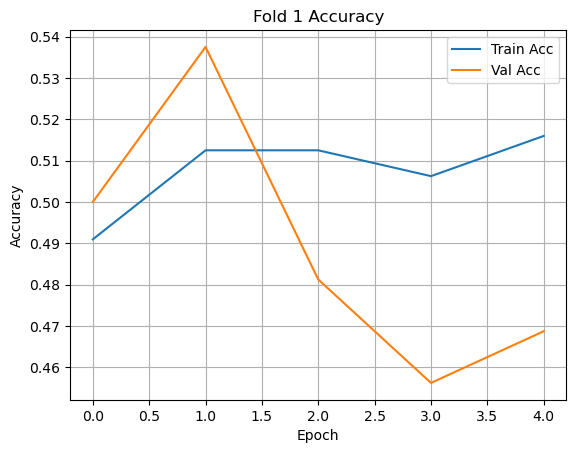

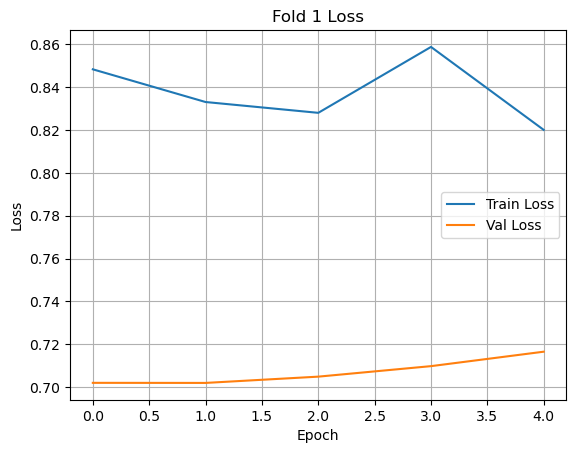

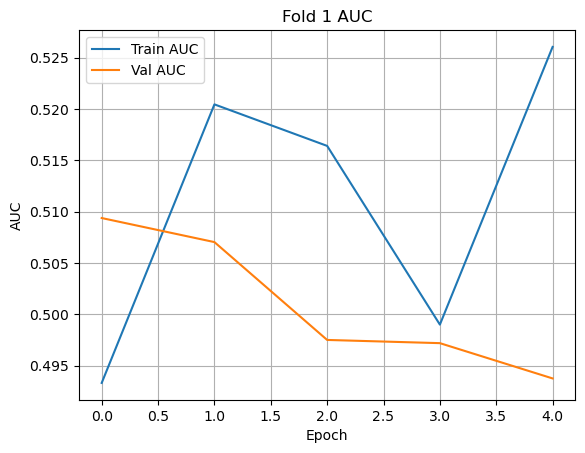

In [15]:
# ==== CÁCH B: đọc lại từ file history.json trên đĩa ====
def load_histories_from_runs(runs_dir="runs"):
    hs = []
    for fp in sorted(glob.glob(os.path.join(runs_dir, "fold_*", "history.json"))):
        with open(fp, "r", encoding="utf-8") as f:
            hs.append(json.load(f))
    return hs

histories = load_histories_from_runs("runs")
plot_from_histories(histories)


In [ ]:
# Save mô hình fold cuối cùng
model.save("mobilenetv2_faceplus_final.h5")


In [17]:
import pandas as pd
import numpy as np

# Giả sử bạn đã có 'results' (list[dict])
results_df = pd.DataFrame(results)
print("🧾 Columns:", list(results_df.columns))

def summarize_metric(df, col):
    s = pd.to_numeric(df[col], errors='coerce')
    mean = s.mean()
    std  = s.std(ddof=1)
    rng  = s.max() - s.min()
    cv   = (std/mean*100) if mean not in (0, np.nan) else np.nan
    print(f"\n🔹 {col}")
    print(f"   Mean   : {mean:.4f}")
    print(f"   Std    : {std:.4f}")
    print(f"   Range  : {rng:.4f}")
    print(f"   CV%    : {cv:.2f}%")

# 1) Tóm tắt tất cả cột liên quan tới accuracy (đuôi 'accuracy')
acc_cols = [c for c in results_df.columns if c.lower().endswith('accuracy')]
if not acc_cols:
    print("⚠️ Không tìm thấy cột *accuracy*. Kiểm tra tên cột trong results_df.columns.")
else:
    for c in acc_cols:
        summarize_metric(results_df, c)
    # 2) Best accuracy per fold (lấy max theo hàng giữa các phương án, vd: base vs hmm vs tta)
    if len(acc_cols) > 1:
        results_df['acc_best'] = results_df[acc_cols].max(axis=1, numeric_only=True)
        summarize_metric(results_df, 'acc_best')

# (tuỳ chọn) Làm tương tự cho F1/AUC nếu có
for suffix in ['f1', 'auc', 'auc_ovr']:
    cols = [c for c in results_df.columns if c.lower().endswith(suffix)]
    for c in cols:
        summarize_metric(results_df, c)

# Xem bảng tổng hợp số liệu số
print("\n📊 Trung bình theo cột (numeric-only):")
print(results_df.mean(numeric_only=True))

# Hiển thị bảng kết quả cuối cùng
results_df


🧾 Columns: ['fold', 'base_accuracy', 'base_precision', 'base_recall', 'base_f1', 'base_auc', 'hmm_accuracy', 'hmm_precision', 'hmm_recall', 'hmm_f1', 'hmm_auc']

🔹 base_accuracy
   Mean   : 0.7625
   Std    : 0.0322
   Range  : 0.0825
   CV%    : 4.22%

🔹 hmm_accuracy
   Mean   : 0.9870
   Std    : 0.0277
   Range  : 0.0625
   CV%    : 2.81%

🔹 acc_best
   Mean   : 0.9870
   Std    : 0.0277
   Range  : 0.0625
   CV%    : 2.81%

🔹 base_f1
   Mean   : 0.7912
   Std    : 0.0222
   Range  : 0.0448
   CV%    : 2.81%

🔹 hmm_f1
   Mean   : 0.9875
   Std    : 0.0266
   Range  : 0.0600
   CV%    : 2.69%

🔹 base_auc
   Mean   : 0.8716
   Std    : 0.0213
   Range  : 0.0488
   CV%    : 2.44%

🔹 hmm_auc
   Mean   : 0.8716
   Std    : 0.0213
   Range  : 0.0488
   CV%    : 2.44%

📊 Trung bình theo cột (numeric-only):
fold              3.000000
base_accuracy     0.762500
base_precision    0.710792
base_recall       0.900000
base_f1           0.791189
base_auc          0.871635
hmm_accuracy      0.9870

,fold,base_accuracy,base_precision,base_recall,base_f1,base_auc,hmm_accuracy,hmm_precision,hmm_recall,hmm_f1,hmm_auc,acc_best
0,1,0.7900,0.745763,0.880,0.807339,0.866025,1.0000,1.000000,1.00,1.000000,0.866025,1.0000
1,2,0.7800,0.712121,0.940,0.810345,0.901075,0.9975,0.995025,1.00,0.997506,0.901075,0.9975
2,3,0.7650,0.757282,0.780,0.768473,0.852275,1.0000,1.000000,1.00,1.000000,0.852275,1.0000
3,4,0.7700,0.700000,0.945,0.804255,0.885625,1.0000,1.000000,1.00,1.000000,0.885625,1.0000
4,5,0.7075,0.638796,0.955,0.765531,0.853175,0.9375,0.903226,0.98,0.940048,0.853175,0.9375
